In [1]:
import pandas as pd
import numpy as np
import time
import joblib
import io
import warnings
from google.colab import files
from tqdm.notebook import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU, Input

warnings.filterwarnings('ignore')

uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f"\nDuplicates Before: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Duplicates After: {df.duplicated().sum()}")

print("\n--- Target Variable Distribution ---")
print(f"Target Distribution Before SMOTE:\n{df['FLAG'].value_counts()}")

df.columns = df.columns.str.replace(' ', '_')
df.drop(columns=['Unnamed:_0', 'Index', 'Address'], inplace=True, errors='ignore')
df = pd.get_dummies(df, drop_first=True)

X = df.drop(columns='FLAG')
y = df['FLAG']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=85, stratify=y)

X_train.fillna(X_train.mean(), inplace=True)
X_test.fillna(X_train.mean(), inplace=True)

print("\n--- Feature Engineering & Splitting ---")
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Target Distribution After SMOTE:\n{y_train_sm.value_counts()}")

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_sm)
X_test_sc = scaler.transform(X_test)

performance_results = []

ml_models = {
    "XGBoost": XGBClassifier(scale_pos_weight=3, random_state=42),
    "LightGBM": LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

print("\n--- Training 5 Models (Including DL) ---")
for name, model in tqdm(ml_models.items(), desc="Training ML Models"):
    start_time = time.time()
    model.fit(X_train_sc, y_train_sm)
    end_time = time.time()

    y_pred = model.predict(X_test_sc)

    performance_results.append({
        "Model Name": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall (Fraud)": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "Time (Seconds)": end_time - start_time
    })
    joblib.dump(model, f"{name.lower().replace(' ', '_')}_model.pkl")

print("Training TensorFlow DNN...")
start_time = time.time()
dnn = Sequential([
    Input(shape=(X_train_sc.shape[1],)),
    Dense(256),
    BatchNormalization(),
    LeakyReLU(negative_slope=0.1),
    Dropout(0.3),
    Dense(128),
    BatchNormalization(),
    LeakyReLU(negative_slope=0.1),
    Dense(1, activation='sigmoid')
])
dnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
dnn.fit(X_train_sc, y_train_sm, epochs=30, batch_size=32, verbose=0)
end_time = time.time()

y_prob = dnn.predict(X_test_sc, verbose=0)
y_pred_dnn = (y_prob > 0.4).astype(int)

performance_results.append({
    "Model Name": "TensorFlow DNN",
    "Accuracy": accuracy_score(y_test, y_pred_dnn),
    "Precision": precision_score(y_test, y_pred_dnn),
    "Recall (Fraud)": recall_score(y_test, y_pred_dnn),
    "F1-Score": f1_score(y_test, y_pred_dnn),
    "Time (Seconds)": end_time - start_time
})

print("\n--- Final Performance Comparison ---")
results_df = pd.DataFrame(performance_results)
print(results_df.to_string(index=False))

dnn.save('tensorflow_dnn.keras')
joblib.dump(scaler, 'scaler.pkl')
print("\nSaving models for deployment...")
print("All models saved successfully! Download them for your Streamlit app.")

Saving transaction_dataset.csv to transaction_dataset.csv

Duplicates Before: 0
Duplicates After: 0

--- Target Variable Distribution ---
Target Distribution Before SMOTE:
FLAG
0    7662
1    2179
Name: count, dtype: int64

--- Feature Engineering & Splitting ---
Target Distribution After SMOTE:
FLAG
0    6129
1    6129
Name: count, dtype: int64

--- Training 5 Models (Including DL) ---


Training ML Models:   0%|          | 0/5 [00:00<?, ?it/s]

Training TensorFlow DNN...

--- Final Performance Comparison ---
         Model Name  Accuracy  Precision  Recall (Fraud)  F1-Score  Time (Seconds)
            XGBoost  0.994413   1.000000        0.974771  0.987224        5.791535
           LightGBM  0.994921   1.000000        0.977064  0.988399        1.312171
      Random Forest  0.990350   1.000000        0.956422  0.977726        5.000733
Logistic Regression  0.977654   0.935556        0.965596  0.950339        1.881247
                KNN  0.966480   0.902174        0.951835  0.926339        0.122719
     TensorFlow DNN  0.974606   0.926991        0.961009  0.943694      100.493391

Saving models for deployment...
All models saved successfully! Download them for your Streamlit app.


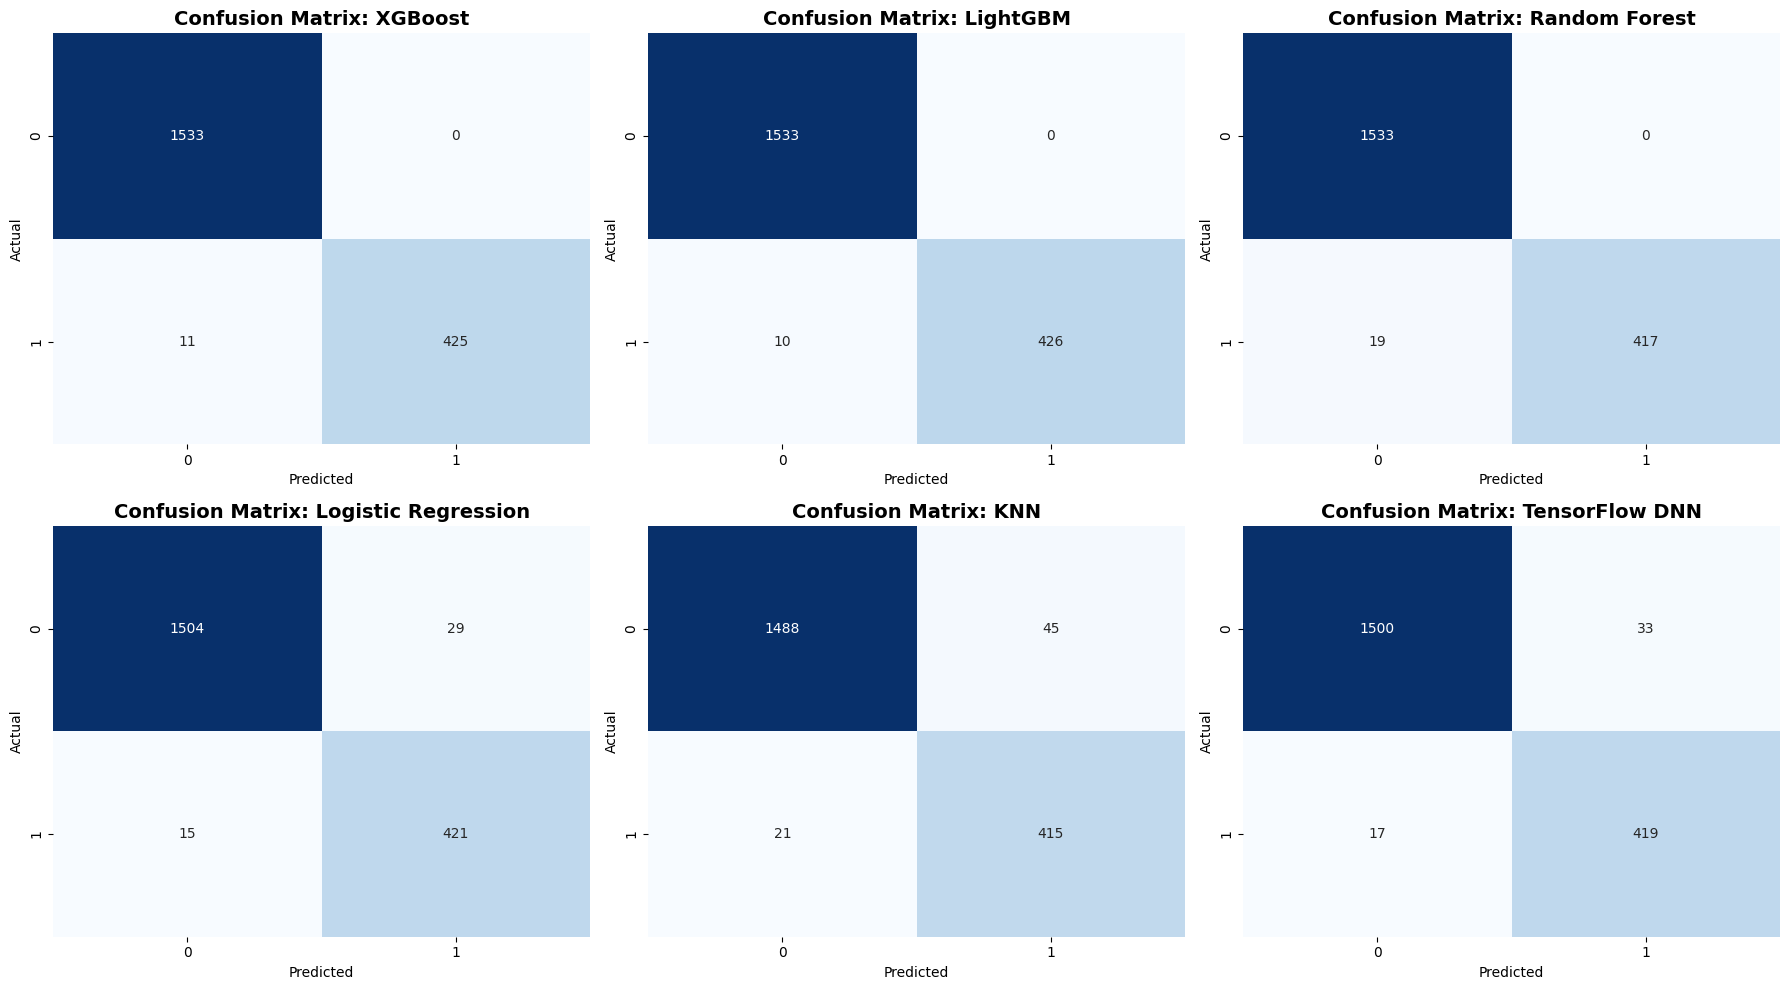

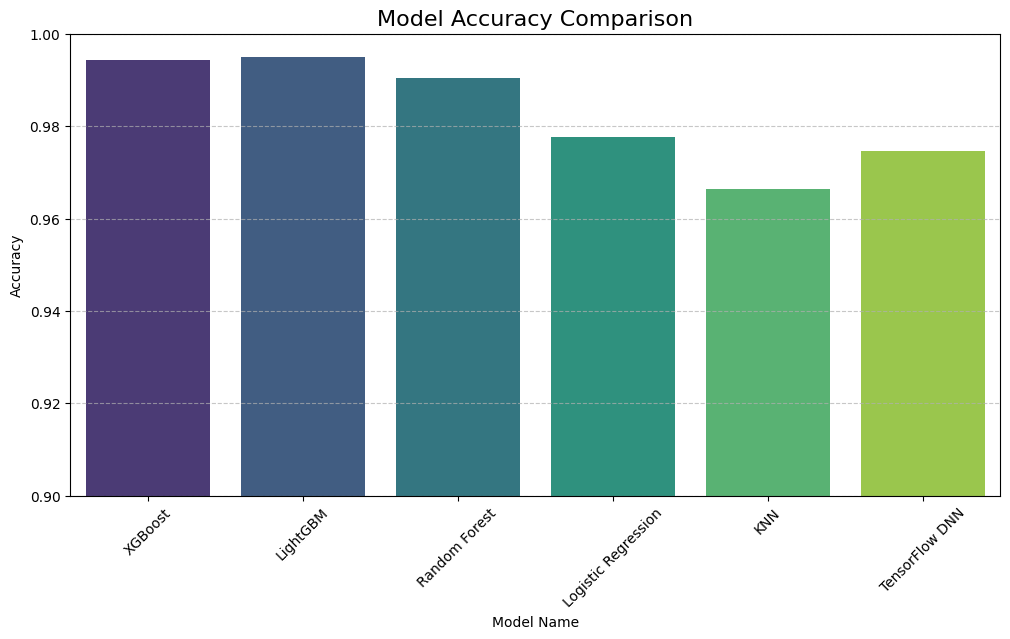

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
all_model_names = list(ml_models.keys()) + ["TensorFlow DNN"]
for i, name in enumerate(all_model_names):
    if name == "TensorFlow DNN":
        y_prob = dnn.predict(X_test_sc, verbose=0)
        y_p = (y_prob > 0.4).astype(int).flatten()
    else:
        y_p = ml_models[name].predict(X_test_sc)

    cm = confusion_matrix(y_test, y_p)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f'Confusion Matrix: {name}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.savefig('accuracy_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
plt.figure(figsize=(12, 6))
sns.barplot(x='Model Name', y='Accuracy', data=results_df, palette='viridis')
plt.title('Model Accuracy Comparison', fontsize=16)
plt.ylim(0.9, 1.0)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()